<a href="https://colab.research.google.com/github/PhuongAnh2212/capstone-project/blob/main/%5BUE%5D_Process_3_frames.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install cv2

ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)
ERROR: No matching distribution found for cv2


In [ ]:
pip install OpenEXR numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 12.3 MB/s eta 0:00:00


In [ ]:
import OpenEXR
import Imath
import numpy as np

def read_exr_image(file_path):
    exr_file = OpenEXR.InputFile(file_path)
    header = exr_file.header()
    dw = header['dataWindow']
    width, height = dw.max.x - dw.min.x + 1, dw.max.y - dw.min.y + 1

    channels = ['R', 'G', 'B']  # Adjust based on your EXR file's channels
    img = [np.frombuffer(exr_file.channel(c, Imath.PixelType(Imath.PixelType.FLOAT)), dtype=np.float32)
           .reshape(height, width) for c in channels]

    return np.stack(img, axis=-1)  # Shape: (H, W, 3)

# Example usage
image = read_exr_image("/content/LevelSequence01.0061.exr")
print(image.shape, image.dtype)


(540, 960, 3) float32


In [ ]:
import matplotlib.pyplot as plt

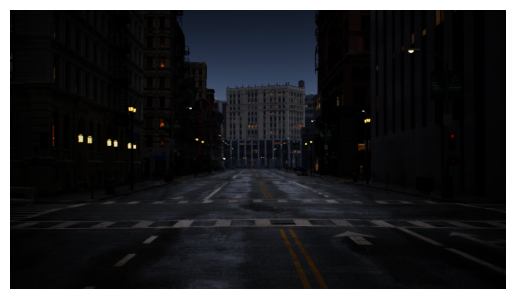

In [ ]:
# Normalize for display (optional, depends on your EXR file values)
image = np.clip(image, 0, 1)

plt.imshow(image)
plt.axis("off")  # Hide axes
plt.show()

(540, 960, 3) float32


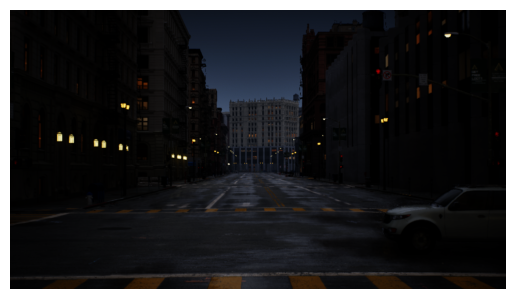

In [ ]:
import OpenEXR
import Imath
import numpy as np

def read_exr_image(file_path):
    exr_file = OpenEXR.InputFile(file_path)
    header = exr_file.header()
    dw = header['dataWindow']
    width, height = dw.max.x - dw.min.x + 1, dw.max.y - dw.min.y + 1

    channels = ['R', 'G', 'B']  # Adjust based on your EXR file's channels
    img = [np.frombuffer(exr_file.channel(c, Imath.PixelType(Imath.PixelType.FLOAT)), dtype=np.float32)
           .reshape(height, width) for c in channels]

    return np.stack(img, axis=-1)  # Shape: (H, W, 3)

# Example usage
image = read_exr_image("/content/LevelSequence01.0026.exr")
print(image.shape, image.dtype)
image = np.clip(image, 0, 1)

plt.imshow(image)
plt.axis("off")  # Hide axes
plt.show()

In [ ]:
import cv2
import os
import shutil

def extract_all_frames(video_path, output_folder):
    """
    Extracts all frames from a 24 FPS video and saves them as images.

    Args:
        video_path (str): Path to the video file.
        output_folder (str): Directory to save the frames.

    Returns:
        str: Path to the zipped folder.
    """
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    cap = cv2.VideoCapture(video_path)
    fps = int(cap.get(cv2.CAP_PROP_FPS))  # Get video FPS (should be 24)

    print(f"Video FPS: {fps}")

    frame_count = 0
    saved_frames = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break  # Stop if video ends

        frame_filename = os.path.join(output_folder, f"frame_{saved_frames:04d}.jpg")
        cv2.imwrite(frame_filename, frame)
        saved_frames += 1
        frame_count += 1

    cap.release()

    # Zip the folder
    zip_filename = output_folder + ".zip"
    shutil.make_archive(output_folder, 'zip', output_folder)

    print(f"Extracted {saved_frames} frames and saved as {zip_filename}")

    return zip_filename

# Example usage
video_path = "/content/Final.mp4"
output_folder = "frames_output_2"
zip_file = extract_all_frames(video_path, output_folder)


Video FPS: 30
Extracted 2359 frames and saved as frames_output_2.zip


In [18]:
import cv2
import os
import shutil

def extract_all_frames(video_path, output_folder):
    """
    Extracts all frames from a 24 FPS video and saves them as images.

    Args:
        video_path (str): Path to the video file.
        output_folder (str): Directory to save the frames.

    Returns:
        str: Path to the zipped folder.
    """
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    cap = cv2.VideoCapture(video_path)
    fps = int(cap.get(cv2.CAP_PROP_FPS))  # Get video FPS (should be 24)

    print(f"Video FPS: {fps}")

    frame_count = 0
    saved_frames = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break  # Stop if video ends

        frame_filename = os.path.join(output_folder, f"frame_{saved_frames:04d}.jpg")
        cv2.imwrite(frame_filename, frame)
        saved_frames += 1
        frame_count += 1

    cap.release()

    # Zip the folder
    zip_filename = output_folder + ".zip"
    shutil.make_archive(output_folder, 'zip', output_folder)

    print(f"Extracted {saved_frames} frames and saved as {zip_filename}")

    return zip_filename

# Example usage
video_path = "/content/1262x708_Final.mp4"
output_folder = "frames_output_3"
zip_file = extract_all_frames(video_path, output_folder)


Video FPS: 30
Extracted 4021 frames and saved as frames_output_3.zip


In [19]:
from google.colab import files  # Only for Google Colab
files.download(zip_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>